In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sqlite3
import folium

In [29]:
df = pd.read_csv('C:\\Users\\H A S E E B\\Documents\\gdg_hackathon\\water_reports.csv')


In [30]:
df.head()

,i009_country,i013_county,i014_subcounty,i016_subloc,i017_vil,i102_wpt_id,wpt_functional,latest_spotcheck_date,Latitude,Longitude,Altitude,Accuracy,source_type
0,Kenya,Kakamega,Kakamega Central,Emukaya,Emakhasa,10070051,Yes,10/16/2023,0.214458,34.618008,1435,5,Protected Spring (not powered by solar/electri...
1,Kenya,Kakamega,Kakamega East,Lunyu,Chiviga,10070052,Yes,1/10/2024,0.281533,34.958183,1624,8,Unprotected Spring
2,Kenya,Kakamega,Kakamega Central,Emukaya,Emulundu,10070054,Yes,1/10/2024,0.241030,34.616890,1546,8,Protected Spring (not powered by solar/electri...
3,Kenya,Kakamega,Kakamega East,Lunyu,Vikusa,10070055,Yes,1/10/2024,0.266997,34.961590,1633,5,Protected Spring (not powered by solar/electri...
4,Kenya,Kakamega,Kakamega East,Ivakale,Makuchi,10070061,Yes,1/19/2024,0.375100,34.904030,1569,8,Protected Spring (not powered by solar/electri...


In [6]:
#show columms
df.columns

Index(['i009_country', 'i013_county', 'i014_subcounty', 'i016_subloc',
       'i017_vil', 'i102_wpt_id', 'wpt_functional', 'latest_spotcheck_date',
       'Latitude', 'Longitude', 'Altitude', 'Accuracy', 'source_type'],
      dtype='str')

In [7]:
#rename columns

df.rename(columns={'i009_country': 'country',  
                   'i013_county': 'county',
                   'i014_subcounty': 'sub_county',
                    'i016_subloc': 'sublocation',
                    'i017_vil': 'village',
                    'i102_wpt_id': 'water_point_id',
                    }, inplace=True)

In [8]:
df.head()

,country,county,sub_county,sublocation,village,water_point_id,wpt_functional,latest_spotcheck_date,Latitude,Longitude,Altitude,Accuracy,source_type
0,Kenya,Kakamega,Kakamega Central,Emukaya,Emakhasa,10070051,Yes,10/16/2023,0.214458,34.618008,1435,5,Protected Spring (not powered by solar/electri...
1,Kenya,Kakamega,Kakamega East,Lunyu,Chiviga,10070052,Yes,1/10/2024,0.281533,34.958183,1624,8,Unprotected Spring
2,Kenya,Kakamega,Kakamega Central,Emukaya,Emulundu,10070054,Yes,1/10/2024,0.241030,34.616890,1546,8,Protected Spring (not powered by solar/electri...
3,Kenya,Kakamega,Kakamega East,Lunyu,Vikusa,10070055,Yes,1/10/2024,0.266997,34.961590,1633,5,Protected Spring (not powered by solar/electri...
4,Kenya,Kakamega,Kakamega East,Ivakale,Makuchi,10070061,Yes,1/19/2024,0.375100,34.904030,1569,8,Protected Spring (not powered by solar/electri...


In [9]:
#drop columns
df.drop(columns=['country',], inplace=True)

In [10]:
df.head()

,county,sub_county,sublocation,village,water_point_id,wpt_functional,latest_spotcheck_date,Latitude,Longitude,Altitude,Accuracy,source_type
0,Kakamega,Kakamega Central,Emukaya,Emakhasa,10070051,Yes,10/16/2023,0.214458,34.618008,1435,5,Protected Spring (not powered by solar/electri...
1,Kakamega,Kakamega East,Lunyu,Chiviga,10070052,Yes,1/10/2024,0.281533,34.958183,1624,8,Unprotected Spring
2,Kakamega,Kakamega Central,Emukaya,Emulundu,10070054,Yes,1/10/2024,0.241030,34.616890,1546,8,Protected Spring (not powered by solar/electri...
3,Kakamega,Kakamega East,Lunyu,Vikusa,10070055,Yes,1/10/2024,0.266997,34.961590,1633,5,Protected Spring (not powered by solar/electri...
4,Kakamega,Kakamega East,Ivakale,Makuchi,10070061,Yes,1/19/2024,0.375100,34.904030,1569,8,Protected Spring (not powered by solar/electri...


In [11]:
#show columns
df.columns


Index(['county', 'sub_county', 'sublocation', 'village', 'water_point_id',
       'wpt_functional', 'latest_spotcheck_date', 'Latitude', 'Longitude',
       'Altitude', 'Accuracy', 'source_type'],
      dtype='str')

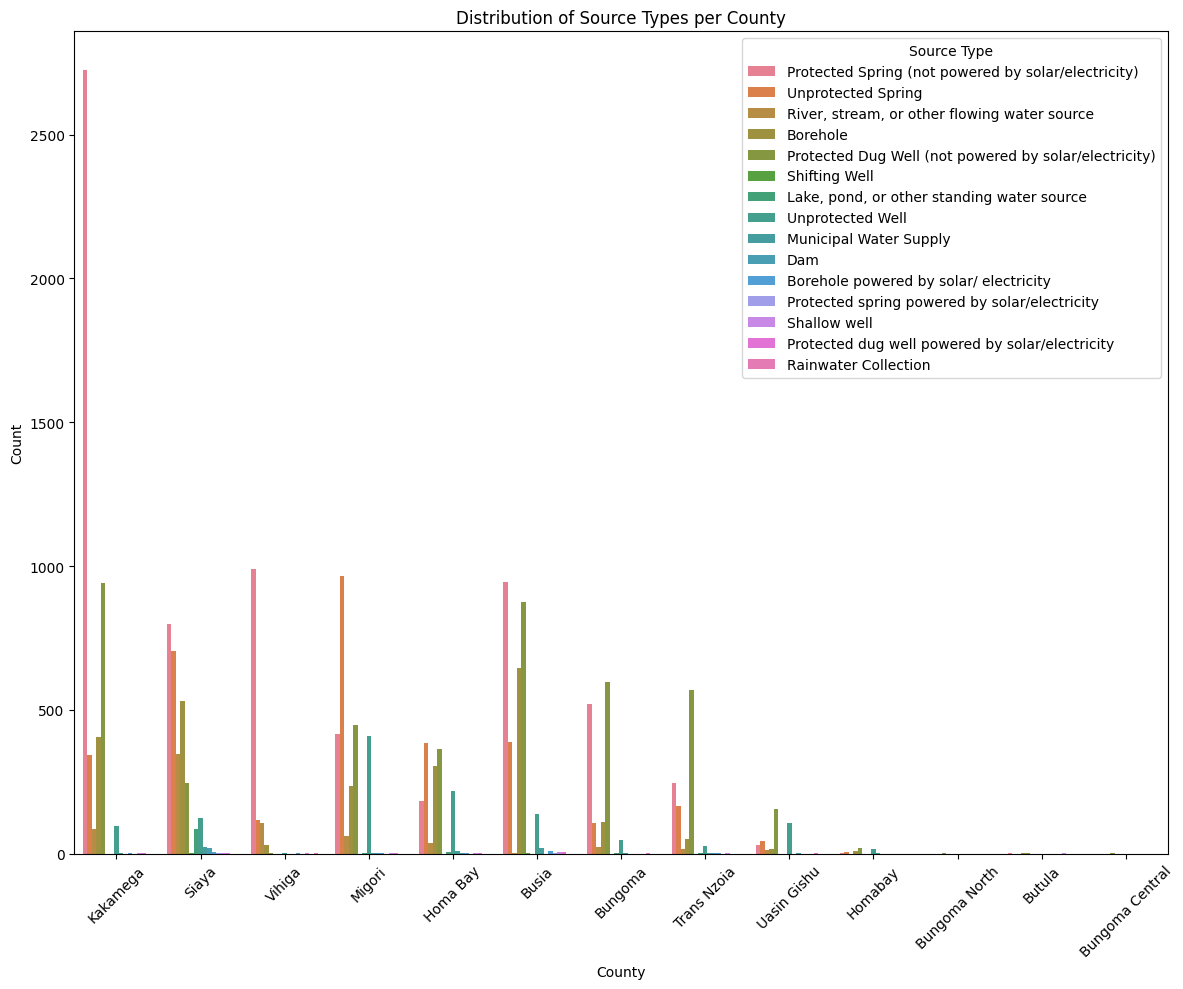

In [12]:
#visualise source types per county
plt.figure(figsize=(12, 10))
sns.countplot(data=df, x='county', hue='source_type')
plt.title('Distribution of Source Types per County')
plt.xlabel('County')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Source Type')
plt.tight_layout()
plt.show()


In [13]:
#print types of source types
print(df['source_type'].unique())


<StringArray>
[  'Protected Spring (not powered by solar/electricity)',
                                    'Unprotected Spring',
          'River, stream, or other flowing water source',
                                              'Borehole',
 'Protected Dug Well (not powered by solar/electricity)',
                                         'Shifting Well',
            'Lake, pond, or other standing water source',
                                      'Unprotected Well',
                                'Municipal Water Supply',
                                                     nan,
                                                   'Dam',
                'Borehole powered by solar/ electricity',
         'Protected spring powered by solar/electricity',
                                          'Shallow well',
       'Protected dug well powered by solar/electricity',
                                  'Rainwater Collection']
Length: 16, dtype: str


In [14]:
#column stats
print(df['source_type'].value_counts())

# Print missing values in new line seoarate from column stats
print("\n")  # Print a new line for separation
print(f"Missing values in each column:\n{df.isnull().sum()}")


source_type
Protected Spring (not powered by solar/electricity)      6856
Protected Dug Well (not powered by solar/electricity)    4225
Unprotected Spring                                       3231
Borehole                                                 2338
Unprotected Well                                         1187
River, stream, or other flowing water source              695
Lake, pond, or other standing water source                 95
Municipal Water Supply                                     59
Dam                                                        29
Borehole powered by solar/ electricity                     27
Shallow well                                               19
Protected dug well powered by solar/electricity            16
Rainwater Collection                                        4
Shifting Well                                               2
Protected spring powered by solar/electricity               2
Name: count, dtype: int64


Missing values in each column:

In [15]:
#drop columns
df.drop(columns=['Accuracy'], inplace=True)

In [16]:
df.head()

,county,sub_county,sublocation,village,water_point_id,wpt_functional,latest_spotcheck_date,Latitude,Longitude,Altitude,source_type
0,Kakamega,Kakamega Central,Emukaya,Emakhasa,10070051,Yes,10/16/2023,0.214458,34.618008,1435,Protected Spring (not powered by solar/electri...
1,Kakamega,Kakamega East,Lunyu,Chiviga,10070052,Yes,1/10/2024,0.281533,34.958183,1624,Unprotected Spring
2,Kakamega,Kakamega Central,Emukaya,Emulundu,10070054,Yes,1/10/2024,0.241030,34.616890,1546,Protected Spring (not powered by solar/electri...
3,Kakamega,Kakamega East,Lunyu,Vikusa,10070055,Yes,1/10/2024,0.266997,34.961590,1633,Protected Spring (not powered by solar/electri...
4,Kakamega,Kakamega East,Ivakale,Makuchi,10070061,Yes,1/19/2024,0.375100,34.904030,1569,Protected Spring (not powered by solar/electri...


In [17]:
import geopandas as gpd
from shapely.geometry import Point

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude))
gdf.crs = "EPSG:4326" 

In [18]:
import folium

# Center around Kenya
m = folium.Map(location=[-1.286389, 36.817223], zoom_start=7)

In [21]:
for _, row in df.iterrows():

    if row["wpt_functional"] == "Yes":
        color = "green"
    else:
        color = "red"

    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"""
        Water Point ID: {row['water_point_id']}<br>
        Village: {row['village']}<br>
        Source: {row['source_type']}<br>
        Functional: {row['wpt_functional']}
        """
    ).add_to(m)

In [22]:
m.save('water_points_map.html')